## Sympy

The ODE is:


Eq(5*D*S*Derivative(p(x), x) + D*Derivative(p(x), (x, 2)) - v*Derivative(p(x), x), 0)


The general solution is:


Eq(p(x), C1 + C2*exp(x*(-5*S + v/D)))


The constants are:


{C1: exp(5*S)/(exp(5*S) - exp(v/D)), C2: -exp(5*S)/(exp(5*S) - exp(v/D))}


The final solution is:


(exp(5*S*x) - exp(v*x/D))*exp(5*S*(1 - x))/(exp(5*S) - exp(v/D))

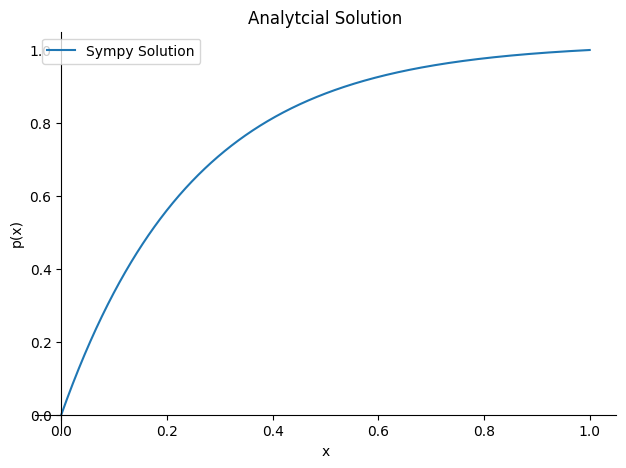

In [57]:
import sympy as sp

x_sym = sp.symbols('x')
D, v, S = sp.symbols('D v S')
p_sympy = sp.Function('p')(x_sym)

T = 300 + 5 * x_sym

ode = sp.Eq(D * sp.diff(p_sympy, x_sym, 2) - v * sp.diff(p_sympy, x_sym) + D * S * sp.diff(p_sympy * sp.diff(T, x_sym), x_sym), 0)
print("The ODE is:")
display(sp.simplify(ode))

solution = sp.dsolve(ode, p_sympy)
print("\nThe general solution is:")
display(solution)

p_sol = solution.rhs
bc1 = sp.Eq(p_sol.subs(x_sym, 0), 0)  
bc2 = sp.Eq(p_sol.subs(x_sym, 1), 1)  

C1, C2 = sp.symbols('C1 C2')
constants = sp.solve([bc1, bc2], (C1, C2))
print("\nThe constants are:")
display(sp.simplify(constants))

p_sympy = sp.simplify(p_sol.subs(constants))
print("\nThe final solution is:")
display(p_sympy)

p_sympy_func = sp.lambdify(x_sym, p_sympy.subs({D:1.0, v:1.0, S:1.0}), "numpy")
sympy_plot = sp.plot(p_sympy_func, (x_sym, 0, 1), title='Analytcial Solution', xlabel='x', ylabel='p(x)', legend=True, label='Sympy Solution')


## Fipy 

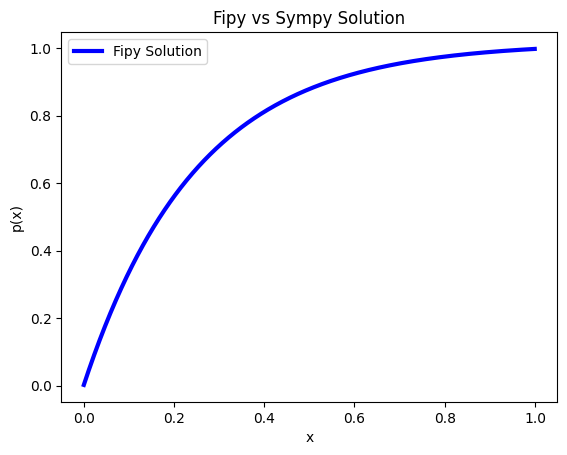

In [58]:
from fipy import CellVariable, FaceVariable, Grid1D, TransientTerm, DiffusionTerm, PowerLawConvectionTerm, Viewer, ConvectionTerm, ImplicitSourceTerm
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

L = 1.0  
nx = 1000  
dx = L / nx  
mesh = Grid1D(nx=nx, dx=dx)

D, v, S = 1.0, 1.0, 1.0 

x = mesh.cellCenters[0]

T = CellVariable(name="Temperature", mesh=mesh, value=300.0 + 5 * x)

p = CellVariable(name="Carrier Concentration", mesh=mesh, value=0.0)

p.constrain(0.0, mesh.facesLeft)
p.constrain(1.0, mesh.facesRight)

v = FaceVariable(mesh=mesh, rank = 1, value=1.0)

eq = (DiffusionTerm(coeff=D)  == PowerLawConvectionTerm(coeff=(v),) - PowerLawConvectionTerm(coeff = D * S * T.faceGrad))

eq.solve(var=p)

plt.plot(x, p.value, label='Fipy Solution', color='blue', linewidth=3)
plt.title('Fipy vs Sympy Solution')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

## Error Calculation

In [59]:
error = np.abs(p.value - p_sympy_func(x.value))
print("Maximum error:", np.max(error))
print("Mean error:", np.mean(error))
print("L2 error:", np.sqrt(np.mean(error**2)))

Maximum error: 0.0024942480840173253
Mean error: 0.0019169072897851486
L2 error: 0.002023164807993386


## Plot Comparison


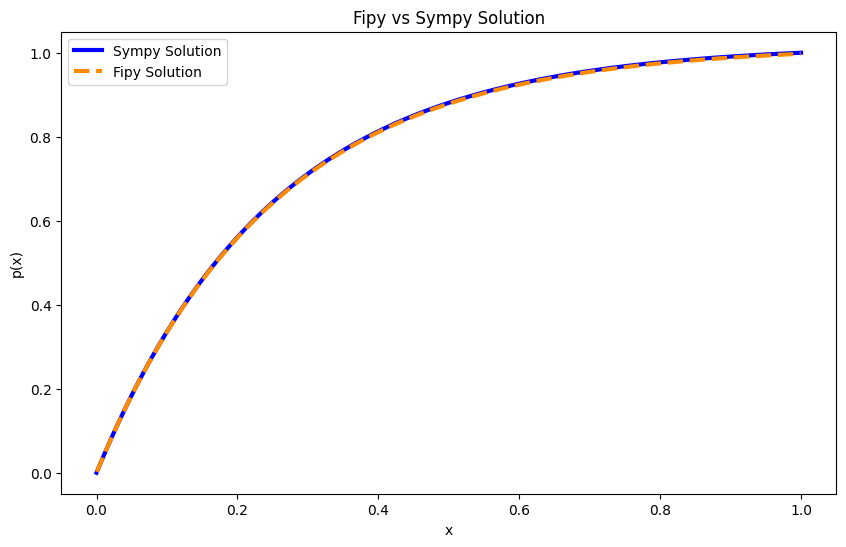

In [60]:
import matplotlib.pyplot as plt

x_exact = np.linspace(0, 1, 100)
p_exact = p_sympy_func(x_exact)

plt.figure(figsize=(10, 6))

plt.plot(x_exact, p_exact, label='Sympy Solution', color='blue', linewidth=3)
plt.plot(x.value, p.value, '--', label='Fipy Solution', color='darkorange', linewidth=3)
plt.title('Fipy vs Sympy Solution')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()